# XGBoost (Extreme Gradient Boosting)

Every model so far fit **one** estimator to the data: one regression line (Day 11/12), one logistic boundary (Day 12), one tree. XGBoost instead builds **hundreds of small decision trees, one after another**, where each new tree is trained to fix the errors the previous trees are still making. That is *boosting*.

**Bagging vs boosting (the one-line difference):**

| | Bagging (e.g. Random Forest) | Boosting (e.g. XGBoost) |
|---|---|---|
| How trees are built | All in **parallel**, each on a random sample | **Sequentially**, each on the previous ensemble's mistakes |
| What each tree sees | The original target `y` | The **residual error** left over so far |
| Goal of adding trees | Reduce variance (average out the noise) | Reduce bias (keep correcting what is still wrong) |
| Failure mode | Rarely overfits, can underfit | Overfits if too many trees are added -> needs early stopping |

Because each tree only patches the leftover error, the trees can stay **shallow** (`max_depth=4` here) and still combine into a very strong model. The price is the last row of that table: boosting will happily keep memorising the training set, so this notebook spends real effort on a **validation set + early stopping** to decide when to stop adding trees.

**Task for this notebook:** binary classification on the sklearn *breast cancer* dataset - given 30 measurements taken from a tumour image, predict whether the tumour is **malignant** or **benign**. This is a medical screening problem, which is why later on we care far more about *recall on the malignant class* (how many cancers we caught) than about plain accuracy.

## Installing XGBoost

XGBoost is **not** part of scikit-learn, it is a separate library, so it needs its own install (the line stays commented out because it only has to run once). It does ship with a scikit-learn compatible API - `XGBClassifier` / `XGBRegressor` expose the same `.fit()` / `.predict()` / `.score()` methods as any sklearn estimator, so everything learned in the previous notebooks still applies.

In [504]:
# %pip install xgboost

## Imports

- **`XGBClassifier`** - the classification flavour (predicts a category). `XGBRegressor` is the same algorithm for predicting a number, kept commented out as a reminder that the choice follows the target.
- **`load_breast_cancer`** - a small dataset bundled with sklearn, so there is no CSV to load this time.
- **The metrics block** - accuracy / precision / recall / F1 were introduced in Day 12; `roc_auc_score` is new and is the metric that judges the model *independently of the 0.5 decision threshold*.
- **`ConfusionMatrixDisplay` / `RocCurveDisplay`** - the plotting helpers for those two metrics.

In [505]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

# from xgboost import XGBRegressor
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)


def section(title):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

In [506]:
import xgboost
import sklearn

print("XGBoost version:", xgboost.__version__)
print("Sklearn version:", sklearn.__version__)

XGBoost version: 3.4.1
Sklearn version: 1.9.0


## Data Loading & Exploration

`load_breast_cancer()` returns a *Bunch* object (a dict with attribute access), not a DataFrame: `.data` is the feature matrix `X`, `.target` is the label vector `y`, and `.feature_names` / `.target_names` hold the human-readable names. The 30 features are 10 base measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) each reported three ways - **mean**, **error** (standard error) and **worst** (the mean of the three largest values in the image).

In [507]:
data = load_breast_cancer()

X = data.data
y = data.target
feature_names = data.feature_names
classes = data.target_names

print(f"Features: {feature_names}  \n")
print(f"Classes: {data.target_names}  \n")

print(f"X shape: {X.shape}  \n")

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']  

Classes: ['malignant' 'benign']  

X shape: (569, 30)  



**569 samples x 30 features**, all numeric and already clean - no nulls, no duplicates, no text to vectorise, which is why there is no data-cleaning section like Day 12 had. Note that the features sit on wildly different scales (`mean area` is in the hundreds, `mean smoothness` is ~0.1); that would matter for logistic regression, but **tree models need no scaling** - a tree only ever asks "is this feature above or below some split value?", and that question is unaffected by units.

## Class Distribution (and what the labels actually mean)

Get the label mapping right before anything else - every metric below reads differently if the classes are flipped. sklearn aligns `target_names` with the integer label by **position**, so `target_names[0]` is what `0` means:

- **`0` = malignant** = the tumour **is** cancerous -> the class we must not miss.
- **`1` = benign** = the tumour is **not** cancerous.

The unintuitive part: the *dangerous* class is `0`, while sklearn's `precision_score` / `recall_score` report the **positive class (`1`, benign)** by default. So the default recall answers *"of all healthy patients, how many did we clear?"* - not the question that matters clinically. That is why `pos_label=0` shows up further down.

In [508]:
# Confirm the label -> name mapping instead of assuming it
for label, name in enumerate(classes):
    print(f"{label} = {name}")

print(f"\nClass distribution:\n{pd.Series(y).value_counts()}")
print(f"\nClass share:\n{pd.Series(y).value_counts(normalize=True).round(4)}")

0 = malignant
1 = benign

Class distribution:
1    357
0    212
Name: count, dtype: int64

Class share:
1    0.6274
0    0.3726
Name: proportion, dtype: float64


**357 benign (1) vs 212 malignant (0)** - roughly **63% / 37%**. That is *mildly* imbalanced: nothing like Day 12's 88/12 text data, but skewed enough that always answering "benign" would already score ~63% accuracy. Two consequences carried through the rest of the notebook:

1. **Stratify every split**, so all three sets keep that same 63/37 ratio.
2. **Do not judge the model on accuracy alone** - report per-class recall, where a missed cancer is visible.

## Train / Validation / Test Split

Day 12 used a plain **two-way** split (train/test). Boosting needs a **three-way** split, because of a subtlety: XGBoost has to decide *how many trees to build*, and that decision must be made against data the trees were not trained on. If the test set were used for it, the test set would have influenced the model, and its score would stop being an honest estimate of unseen performance.

| Split | Size here | What it is for |
|---|---|---|
| **Train** (70%) | 398 rows | Fit the trees |
| **Validation** (15%) | 85 rows | Decide *when to stop* adding trees (early stopping) + tune hyperparameters |
| **Test** (15%) | 86 rows | Touched **once**, at the very end, for the honest score |

sklearn has no three-way splitter, so it takes **two calls**: first peel off 30% as a temporary block, then cut that block in half (50% of 30% = 15% each). `stratify` is passed to **both** calls - on the second one it must be `stratify=y_temp` (the labels of the block being split), not `y`, whose length no longer matches.

In [509]:
# First: 70% train, 30% temporary block
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second: split the temporary block 50/50
# Finally, we have 70% train, 15% validation, 15% test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp,
)

section("DATA SET SPLITS")
print("Training set:   ", X_train.shape)
print("Validation set: ", X_validation.shape)
print("Test set:       ", X_test.shape)

section("CLASS BALANCE PER SPLIT (0 = malignant, 1 = benign)")
for name, labels in [
    ("Train", y_train),
    ("Validation", y_validation),
    ("Test", y_test),
]:
    counts = np.bincount(labels)
    print(
        f"{name:<11} malignant={counts[0]:>3}  benign={counts[1]:>3}  "
        f"({counts[1] / counts.sum():.1%} benign)"
    )


DATA SET SPLITS
Training set:    (398, 30)
Validation set:  (85, 30)
Test set:        (86, 30)

CLASS BALANCE PER SPLIT (0 = malignant, 1 = benign)
Train       malignant=148  benign=250  (62.8% benign)
Validation  malignant= 32  benign= 53  (62.4% benign)
Test        malignant= 32  benign= 54  (62.8% benign)


**398 / 85 / 86 rows**, and every split sits at ~62-63% benign - the stratification worked, so the test score will not be distorted by a lucky or unlucky class mix. With only **32 malignant cases in the test set**, each missed cancer moves recall by ~3 percentage points, which is worth remembering while reading the metrics below.

## Model Training (with Early Stopping)

`LinearRegression()` and `LogisticRegression()` needed almost no configuration. XGBoost is the opposite - its behaviour lives in its hyperparameters, and these are the ones that matter most:

| Parameter | Value | What it does |
|---|---|---|
| `n_estimators` | 500 | **Maximum** number of trees. With early stopping on, this is a ceiling, not a target. |
| `learning_rate` (`eta`) | 0.1 | **Shrinks every tree's contribution** before it is added to the running prediction - the step size of the boosting walk. Gets its own deep-dive right after this section, since it is one of the two knobs (with `max_depth`) most worth understanding early. |
| `max_depth` | 4 | How deep each tree may go. Boosted trees are deliberately **shallow** ("weak learners") - depth 4 = at most 4 questions per tree. Increase to see overfitting appear, decrease to see underfitting; `3 <= depth <= 6` is the usual working range. |
| `subsample` | 0.8 | Each tree sees a random 80% of the **rows**, which adds randomness and fights overfitting. |
| `colsample_bytree` | 0.8 | Each tree sees a random 80% of the **features**, for the same reason. |
| `eval_metric` | `logloss` | The score watched on the validation set. Log loss punishes *confident* wrong answers, so it is more informative than accuracy. |
| `early_stopping_rounds` | 20 | **Stop if validation log loss has not improved for 20 consecutive trees**, and keep the best iteration. This is what prevents the "boosting keeps memorising" failure mode. |

`eval_set` supplies the data early stopping watches. Both train and validation are listed so the learning curve below can show them together - but only the **last** entry (`validation_1`) drives the stopping decision.

In [510]:
model = XGBClassifier(
    max_depth=4,  # Controls how many levels of feature-based decisions each tree can make; 3–6 is a good range
    # Recommended: 3–6
    learning_rate=0.05,  # Controls how much each tree contributes; lower = slower but often better generalization
    # Recommended: 0.01–0.1
    n_estimators=1000,  # Number of trees; too few can underfit, too many can overfit
    # Recommended: 100–1000 (use early stopping)
    eval_metric="logloss",  # Measures prediction error during training; lower is better
    # Recommended: "logloss" for binary classification
    random_state=42,  # Controls the randomness in the model so you get the same results each time you train it.
    subsample=0.8,  # Prevents the model from becoming too dependent on dominant rows and reduces overfitting
    # Uses a random 80% of rows for each tree; reduces overfitting
    # Recommended: 0.7–1.0
    colsample_bytree=0.8,  # Uses a random 80% of features for each tree; reduces dependence on the same features
    # Recommended: 0.7–1.0
    early_stopping_rounds=30,  # Stops training if performance doesn't improve for 20 trees
    # Recommended: 10–50
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_validation, y_validation)],
    verbose=True,
)


[0]	validation_0-logloss:0.61988	validation_1-logloss:0.61967
[1]	validation_0-logloss:0.58244	validation_1-logloss:0.58317
[2]	validation_0-logloss:0.54786	validation_1-logloss:0.54808
[3]	validation_0-logloss:0.51762	validation_1-logloss:0.51790
[4]	validation_0-logloss:0.48884	validation_1-logloss:0.48813
[5]	validation_0-logloss:0.46301	validation_1-logloss:0.46113
[6]	validation_0-logloss:0.43899	validation_1-logloss:0.43624
[7]	validation_0-logloss:0.41616	validation_1-logloss:0.41339
[8]	validation_0-logloss:0.39527	validation_1-logloss:0.39021
[9]	validation_0-logloss:0.37581	validation_1-logloss:0.37082


[10]	validation_0-logloss:0.35745	validation_1-logloss:0.35363
[11]	validation_0-logloss:0.34077	validation_1-logloss:0.33651
[12]	validation_0-logloss:0.32498	validation_1-logloss:0.31952
[13]	validation_0-logloss:0.31012	validation_1-logloss:0.30500
[14]	validation_0-logloss:0.29649	validation_1-logloss:0.29118
[15]	validation_0-logloss:0.28349	validation_1-logloss:0.27816
[16]	validation_0-logloss:0.27143	validation_1-logloss:0.26579
[17]	validation_0-logloss:0.25990	validation_1-logloss:0.25423
[18]	validation_0-logloss:0.24896	validation_1-logloss:0.24421
[19]	validation_0-logloss:0.23840	validation_1-logloss:0.23362
[20]	validation_0-logloss:0.22890	validation_1-logloss:0.22427
[21]	validation_0-logloss:0.21933	validation_1-logloss:0.21548
[22]	validation_0-logloss:0.21079	validation_1-logloss:0.20718
[23]	validation_0-logloss:0.20241	validation_1-logloss:0.19887
[24]	validation_0-logloss:0.19437	validation_1-logloss:0.19227
[25]	validation_0-logloss:0.18633	validation_1-logloss:

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [511]:
results = model.evals_result()
train_logloss = results["validation_0"]["logloss"]
val_logloss = results["validation_1"]["logloss"]

section("EARLY STOPPING")
print(f"Trees allowed (n_estimators):  {model.n_estimators}")
print(f"Best iteration:                {model.best_iteration}")
print(f"Trees actually used:           {model.best_iteration + 1}")
print(f"Validation logloss (1st tree): {val_logloss[0]:.4f}")
print(f"Validation logloss (best):     {val_logloss[model.best_iteration]:.5f}")
print(f"Training   logloss (best):     {train_logloss[model.best_iteration]:.5f}")



EARLY STOPPING
Trees allowed (n_estimators):  1000
Best iteration:                470
Trees actually used:           471
Validation logloss (1st tree): 0.6197
Validation logloss (best):     0.02338
Training   logloss (best):     0.00814


## Training / Validation curves


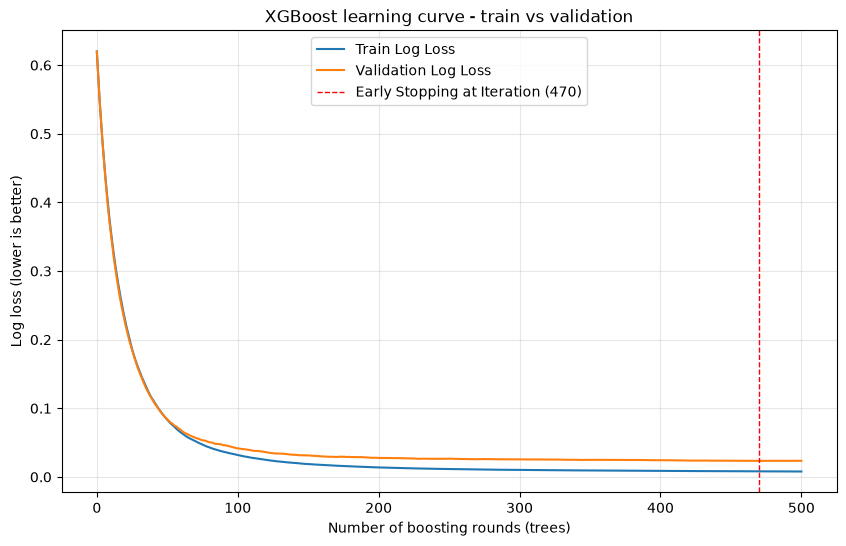

In [512]:
plt.figure(figsize=(10, 6))
plt.plot(train_logloss, label="Train Log Loss")
plt.plot(val_logloss, label="Validation Log Loss")
plt.axvline(
    model.best_iteration,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Early Stopping at Iteration ({model.best_iteration})",
)
plt.xlabel("Number of boosting rounds (trees)")
plt.ylabel("Log loss (lower is better)")
plt.title("XGBoost learning curve - train vs validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [513]:
print(classification_report(y_test, model.predict(X_test), target_names=classes))

              precision    recall  f1-score   support

   malignant       0.93      0.84      0.89        32
      benign       0.91      0.96      0.94        54

    accuracy                           0.92        86
   macro avg       0.92      0.90      0.91        86
weighted avg       0.92      0.92      0.92        86



In [515]:
model.save_model("xgb_breast_cancer_model.json")
print("Model saved to 'xgb_breast_cancer_model.json'")

Model saved to 'xgb_breast_cancer_model.json'


In [ ]:
loaded_model = XGBClassifier()
loaded_model.load_model("xgb_breast_cancer_model.json")

train_sample = X_train[[0]]  # a single row the model was trained on, kept 2D
train_pred = loaded_model.predict(train_sample)[0]
train_proba = loaded_model.predict_proba(train_sample)[0, 1]
print(
    f"Train-set sample -> predicted: {classes[train_pred]} "
    f"(P(benign)={train_proba:.4f}), actual: {classes[y_train[0]]}"
)

# load the model and predict (new and get output)
new_sample = X_test[[0]]  # unseen row - stands in for a brand-new patient
new_pred = loaded_model.predict(new_sample)[0]
new_proba = loaded_model.predict_proba(new_sample)[0, 1]
print(
    f"New patient      -> predicted: {classes[new_pred]} "
    f"(P(benign)={new_proba:.4f}), actual: {classes[y_test[0]]}"
)

Train-set sample -> predicted: benign (P(benign)=0.9840), actual: benign
New patient      -> predicted: benign (P(benign)=0.9945), actual: benign
